# FINAL RESULTS — control_p231 atomized (per-base SNPs) (filt2 uniform vs filt2 + ω=1/m_b)

6 regimes (rows) × 2 weights (cols: **filt2 uniform** | **filt2 + 1/m_b**). Side-by-side improvement view of the front-runner vs the unweighted baseline on the atomized (per-base SNPs) arm of the p231 benchmark. Three missingness-filter panels + summary table. Record-index join (multiallelic-safe). Memory-streamed per cell.

## Per-record missingness — distribution & CDF for this notebook's scope

For F=231 founders. `missing_per_record = 231 − n_called` (h-independent panel QC, identical across regimes — pulled from one est TSV). Annotated thresholds: 10% / 25% / 50% / 90% of 231 (= 23 / 58 / 115 / 208 missing). Two of these (50% and 90%) match the missingness panels below.

scope=atomized (per-base SNPs)  records: 7,464,709  median #missing: 52  max: 229


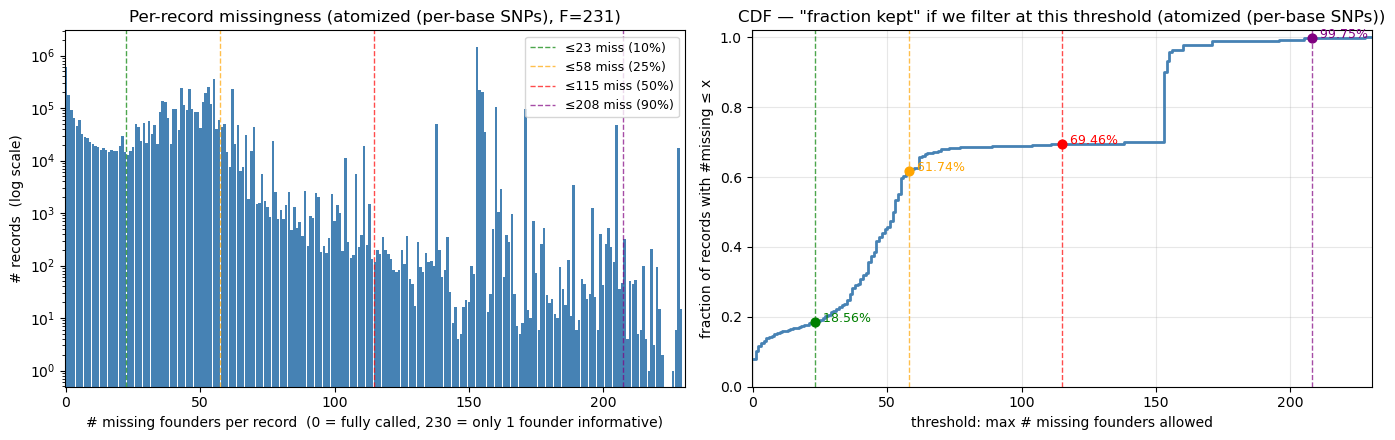

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT_=Path("/carnegie/nobackup/scratch/tbellagio/hapfire_sv/control_p231")
RES_=ROOT_/"results"; PLOTS_=RES_/"plots"; PLOTS_.mkdir(parents=True,exist_ok=True)
F_=231
ARM_='atomized'; CLS_='all'; LAB_='atomized (per-base SNPs)'
ref_est = RES_/f"kmate_global_filt2mb_{ARM_}"/"n50_g0"/f"p231_filt2mb_{ARM_}_n50_g0_cov10_s42.tsv"
df_ = pd.read_csv(ref_est, sep="\t", usecols=["ref_len","alt_len","n_called"])
rl_=df_["ref_len"].values; al_=df_["alt_len"].values
if CLS_=="SNPs": msk_=(rl_==1)&(al_==1)
elif CLS_=="SVs": msk_=np.maximum(rl_,al_)>=50
else: msk_=np.ones(len(df_),bool)
nm_=(F_-df_["n_called"].values[msk_]).astype(int)
print(f"scope={LAB_}  records: {len(nm_):,}  median #missing: {int(np.median(nm_))}  max: {int(nm_.max())}")
fig_,axes_=plt.subplots(1,2,figsize=(14,4.5))
counts_=np.bincount(nm_,minlength=F_+1)
ax_=axes_[0]
ax_.bar(np.arange(F_+1),counts_[:F_+1],width=0.9,color="steelblue",edgecolor="none")
ax_.set_yscale("log"); ax_.set_xlabel(f"# missing founders per record  (0 = fully called, {F_-1} = only 1 founder informative)")
ax_.set_ylabel("# records  (log scale)"); ax_.set_title(f"Per-record missingness ({LAB_}, F={F_})")
ax_.set_xlim(-0.5,F_-0.5)
ANNOT_=[(23,"green","10%"),(58,"orange","25%"),(115,"red","50%"),(208,"purple","90%")]
for n,color,lab in ANNOT_:
    ax_.axvline(n-0.5,color=color,ls="--",lw=1,alpha=0.7,label=f"≤{n} miss ({lab})")
ax_.legend(fontsize=9,loc="upper right")
ax_=axes_[1]
cum_=np.cumsum(counts_[:F_+1])/counts_[:F_+1].sum()
ax_.step(np.arange(F_+1),cum_,where="post",color="steelblue",lw=2)
ax_.set_xlabel("threshold: max # missing founders allowed"); ax_.set_ylabel("fraction of records with #missing ≤ x")
ax_.set_title(f'CDF — "fraction kept" if we filter at this threshold ({LAB_})')
ax_.set_xlim(-0.5,F_-0.5); ax_.set_ylim(0,1.02); ax_.grid(alpha=0.3)
for n,color,lab in ANNOT_:
    f_kept=cum_[n]
    ax_.axvline(n,color=color,ls="--",lw=1,alpha=0.7)
    ax_.scatter([n],[f_kept],color=color,s=40,zorder=5)
    ax_.annotate(f"  {f_kept*100:.2f}%",xy=(n,f_kept),color=color,fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_/f"missingness_cdf_p231_{ARM_}_{CLS_}.png",dpi=130,bbox_inches="tight")
plt.show()

## Setup — load helpers (6 regimes × 2 weights)

In [2]:
import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt, gc, math
from matplotlib.colors import LogNorm
from pathlib import Path
ROOT=Path("/carnegie/nobackup/scratch/tbellagio/hapfire_sv/control_p231")
RES=ROOT/"results"; SIMS=ROOT/"sims"; PLOTS=RES/"plots"; PLOTS.mkdir(parents=True,exist_ok=True)
GREY="#888888"; F=231
ARM='atomized'; CLASS_FILTER='all'
WEIGHTS=["uniform","inv_mb"]
WLABEL={"uniform":"filt2 (uniform)","inv_mb":"filt2 + 1/m_b"}
REGIMES=["n231_g0","n50_g0","n231_g1","n50_g1","n50_g3","n50_g3_dom500"]
ARM_LABEL={
    "atomized":"arch3 atomized (per-base SNPs)",
    "raw":"arch3 raw",
}[ARM]
def subdir(reg):
    if reg=="n50_g3_dom500": return "cov10_n50_g3_s42_hotspots_dom500_p231_chr1"
    n,g=reg.split("_g"); return f"cov10_{n}_g{g}_s42_hotspots_p231_chr1"
def est_path(reg,weight):
    wtag="filt2mb" if weight=="inv_mb" else "filt2u"
    return RES/f"kmate_global_{wtag}_{ARM}"/reg/f"p231_{wtag}_{ARM}_{reg}_cov10_s42.tsv"

def load_cell(reg,weight):
    tp=SIMS/subdir(reg)/f"recomb_truth_{ARM}.tsv.gz"
    ep=est_path(reg,weight)
    tr=pd.read_csv(tp,sep="\t",usecols=["truth_af","ref_len","alt_len"])
    es=pd.read_csv(ep,sep="\t",usecols=["alt_freq","n_called"])
    if len(tr)!=len(es): raise RuntimeError(f"len mismatch {reg}/{weight}")
    rl=tr["ref_len"].values; al=tr["alt_len"].values
    if CLASS_FILTER=="SNPs": msk=(rl==1)&(al==1)
    elif CLASS_FILTER=="SVs": msk=np.maximum(rl,al)>=50
    else: msk=np.ones(len(tr),bool)
    truth=tr["truth_af"].values[msk].astype(np.float32)
    est=es["alt_freq"].values[msk].astype(np.float32)
    miss=((F-es["n_called"].values[msk])/F).astype(np.float32)
    del tr,es; gc.collect()
    return truth,est,miss

def scatter_density(ax,x,y,title,s=15,alpha=0.5,subsample=200_000):
    m=np.isfinite(x)&np.isfinite(y); x=x[m]; y=y[m]
    keep=(x>0)|(y>0); x=x[keep]; y=y[keep]
    if len(x)==0: ax.set_title(f"{title}\n(no data)",fontsize=10,color=GREY); return None
    nb=100
    H,xe,ye=np.histogram2d(x,y,bins=nb,range=[[0,1],[0,1]])
    ix=np.clip(np.digitize(x,xe)-1,0,nb-1); iy=np.clip(np.digitize(y,ye)-1,0,nb-1)
    d=H[ix,iy].astype(np.float32)
    if subsample and len(x)>subsample:
        np.random.seed(42); sel=np.random.choice(len(x),subsample,replace=False); x,y,d=x[sel],y[sel],d[sel]
    cmap=plt.get_cmap("viridis"); norm=LogNorm(vmin=max(d.min(),1),vmax=max(d.max(),1))
    order=np.argsort(d)
    ax.scatter(x[order],y[order],c=d[order],s=s,cmap=cmap,norm=norm,alpha=alpha,edgecolors="none",rasterized=True)
    ax.plot([0,1],[0,1],"--",lw=0.8,alpha=0.7,color=GREY)
    err=y-x; mae=float(np.abs(err).mean()); n=int(np.isfinite(err).sum())
    ax.set_title(f"{title}\nMAE = {mae:.4f}   n = {n:,}",fontsize=10,color=GREY)
    ax.set_xlim(-0.03,1.03); ax.set_ylim(-0.03,1.03); ax.set_aspect("equal",adjustable="box")
    ax.set_xticks([0,.2,.4,.6,.8,1.0]); ax.set_yticks([0,.2,.4,.6,.8,1.0])
    for sp in ("top","right","left","bottom"): ax.spines[sp].set_visible(False)
    ax.tick_params(length=0,colors=GREY); ax.grid(True,color="#dddddd",linewidth=0.7,zorder=0); ax.set_axisbelow(True)
    ax.xaxis.label.set_color(GREY); ax.yaxis.label.set_color(GREY)
    sm=matplotlib.cm.ScalarMappable(norm=norm,cmap=cmap); sm.set_array([]); return sm

def panel(miss_thr,suptitle,filename):
    """6 regimes (rows) x 2 weights (cols: uniform | inv_mb)."""
    CELL=4.0
    fig,axes=plt.subplots(len(REGIMES),len(WEIGHTS),
                          figsize=(CELL*len(WEIGHTS)+1,CELL*len(REGIMES)+0.5),
                          sharex=True,sharey=True)
    last_sm=None
    for i,reg in enumerate(REGIMES):
        for j,w in enumerate(WEIGHTS):
            ax=axes[i,j] if len(REGIMES)>1 else axes[j]
            truth,est,miss=load_cell(reg,w); sel=miss<=miss_thr
            sm=scatter_density(ax,truth[sel],est[sel],title=f"{WLABEL[w]}  ·  {reg}")
            if sm is not None: last_sm=sm
            if j==0: ax.set_ylabel("Estimated AF")
            if i==len(REGIMES)-1: ax.set_xlabel("True AF")
            del truth,est,miss; gc.collect()
    fig.subplots_adjust(bottom=0.06,top=0.96,hspace=0.30,wspace=0.10)
    cax=fig.add_axes([0.25,0.025,0.50,0.008])
    if last_sm is not None:
        cb=fig.colorbar(last_sm,cax=cax,orientation="horizontal",label="Local density (log count of records)")
        cb.outline.set_edgecolor(GREY); cb.ax.xaxis.set_tick_params(color=GREY,labelcolor=GREY); cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(suptitle,y=0.985,fontsize=11,color=GREY)
    plt.savefig(PLOTS/filename,dpi=130,bbox_inches="tight"); plt.show(); plt.close(fig); gc.collect()
    print(f"saved: plots/{filename}")
print(f"helpers ready (ARM={ARM} CLASS_FILTER={CLASS_FILTER} WEIGHTS={WEIGHTS})")

helpers ready (ARM=atomized CLASS_FILTER=all WEIGHTS=['uniform', 'inv_mb'])


## Panel 1 — all records, no filter

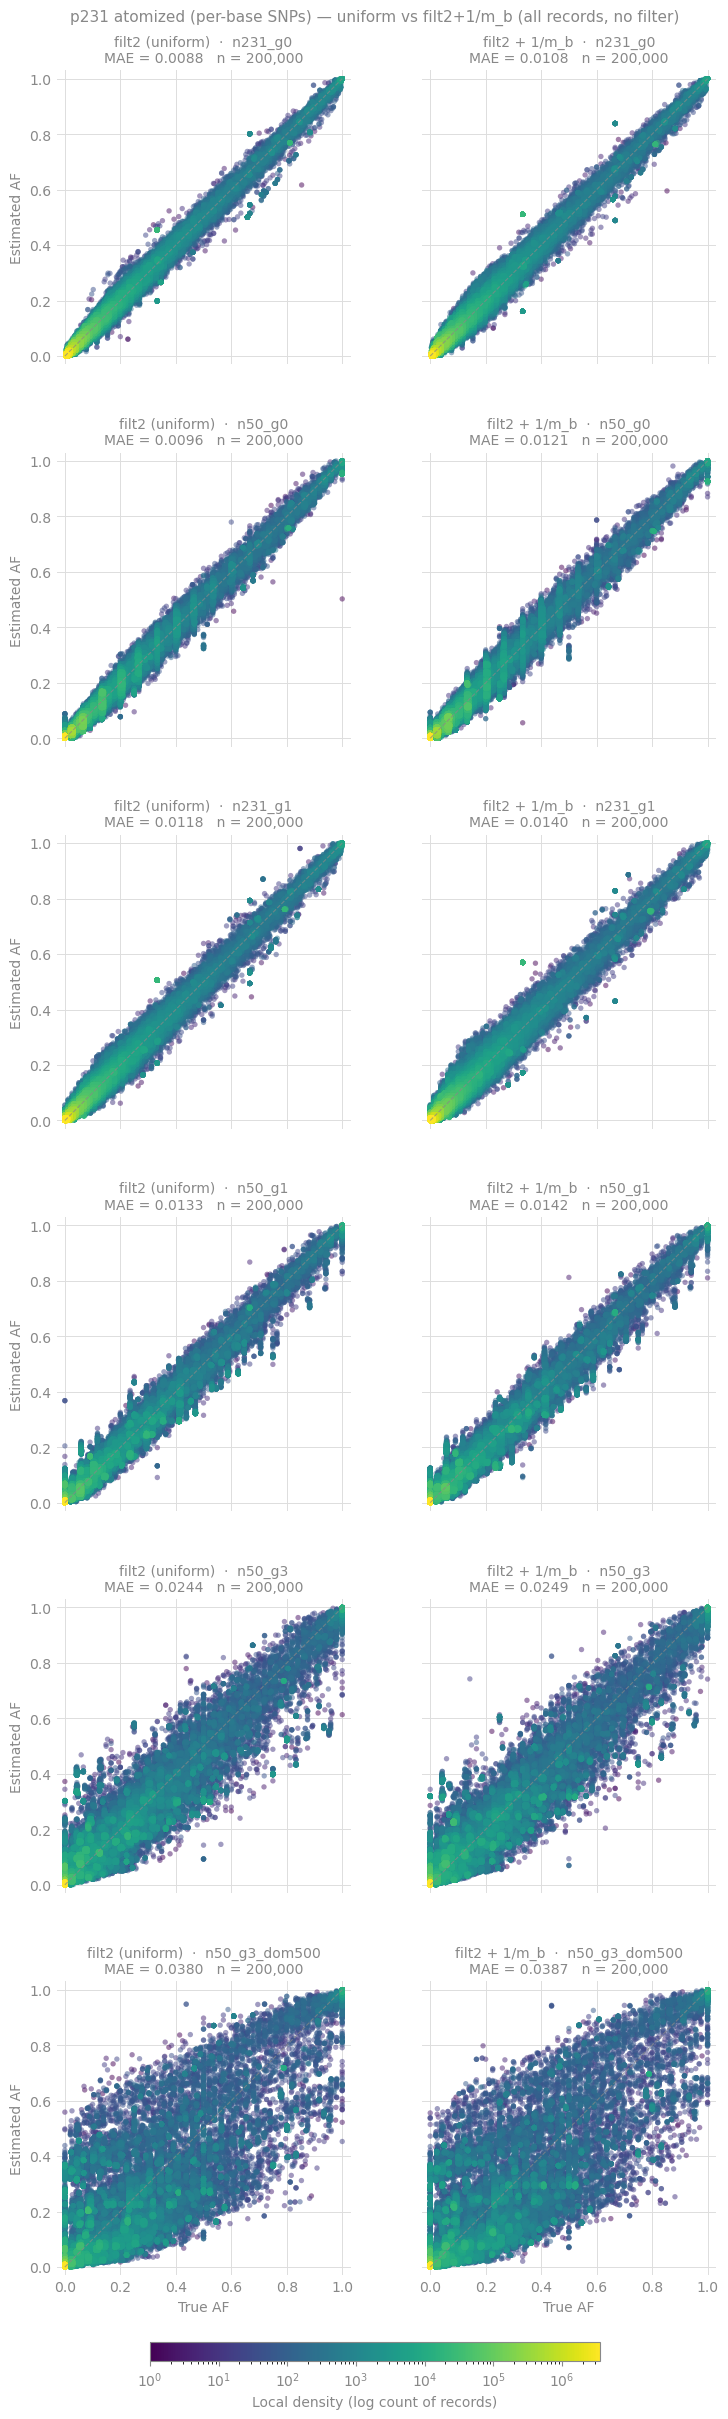

saved: plots/panel_p231_atom_uVm_no_filter.png


In [3]:
panel(miss_thr=2.0, suptitle="p231 atomized (per-base SNPs) — uniform vs filt2+1/m_b (all records, no filter)", filename="panel_p231_atom_uVm_no_filter.png")

## Panel 2 — missing_frac ≤ 0.50

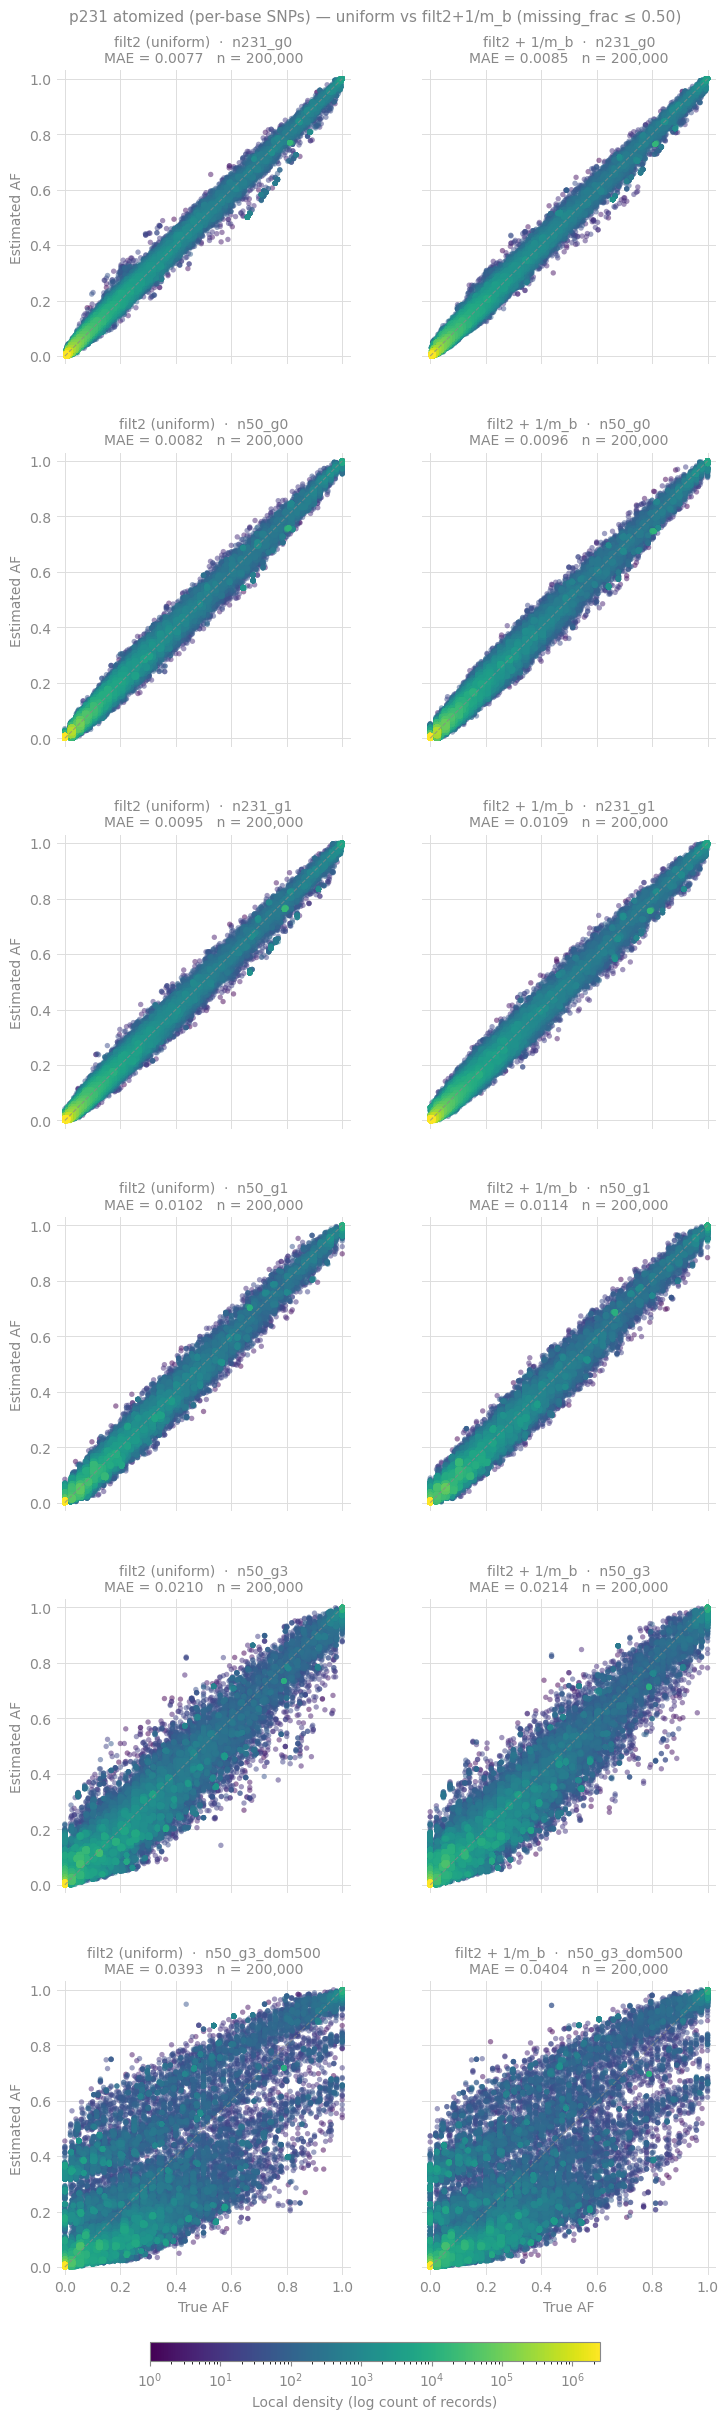

saved: plots/panel_p231_atom_uVm_miss50.png


In [4]:
panel(miss_thr=0.5, suptitle="p231 atomized (per-base SNPs) — uniform vs filt2+1/m_b (missing_frac ≤ 0.50)", filename="panel_p231_atom_uVm_miss50.png")

## Panel 3 — missing_frac ≤ 0.90

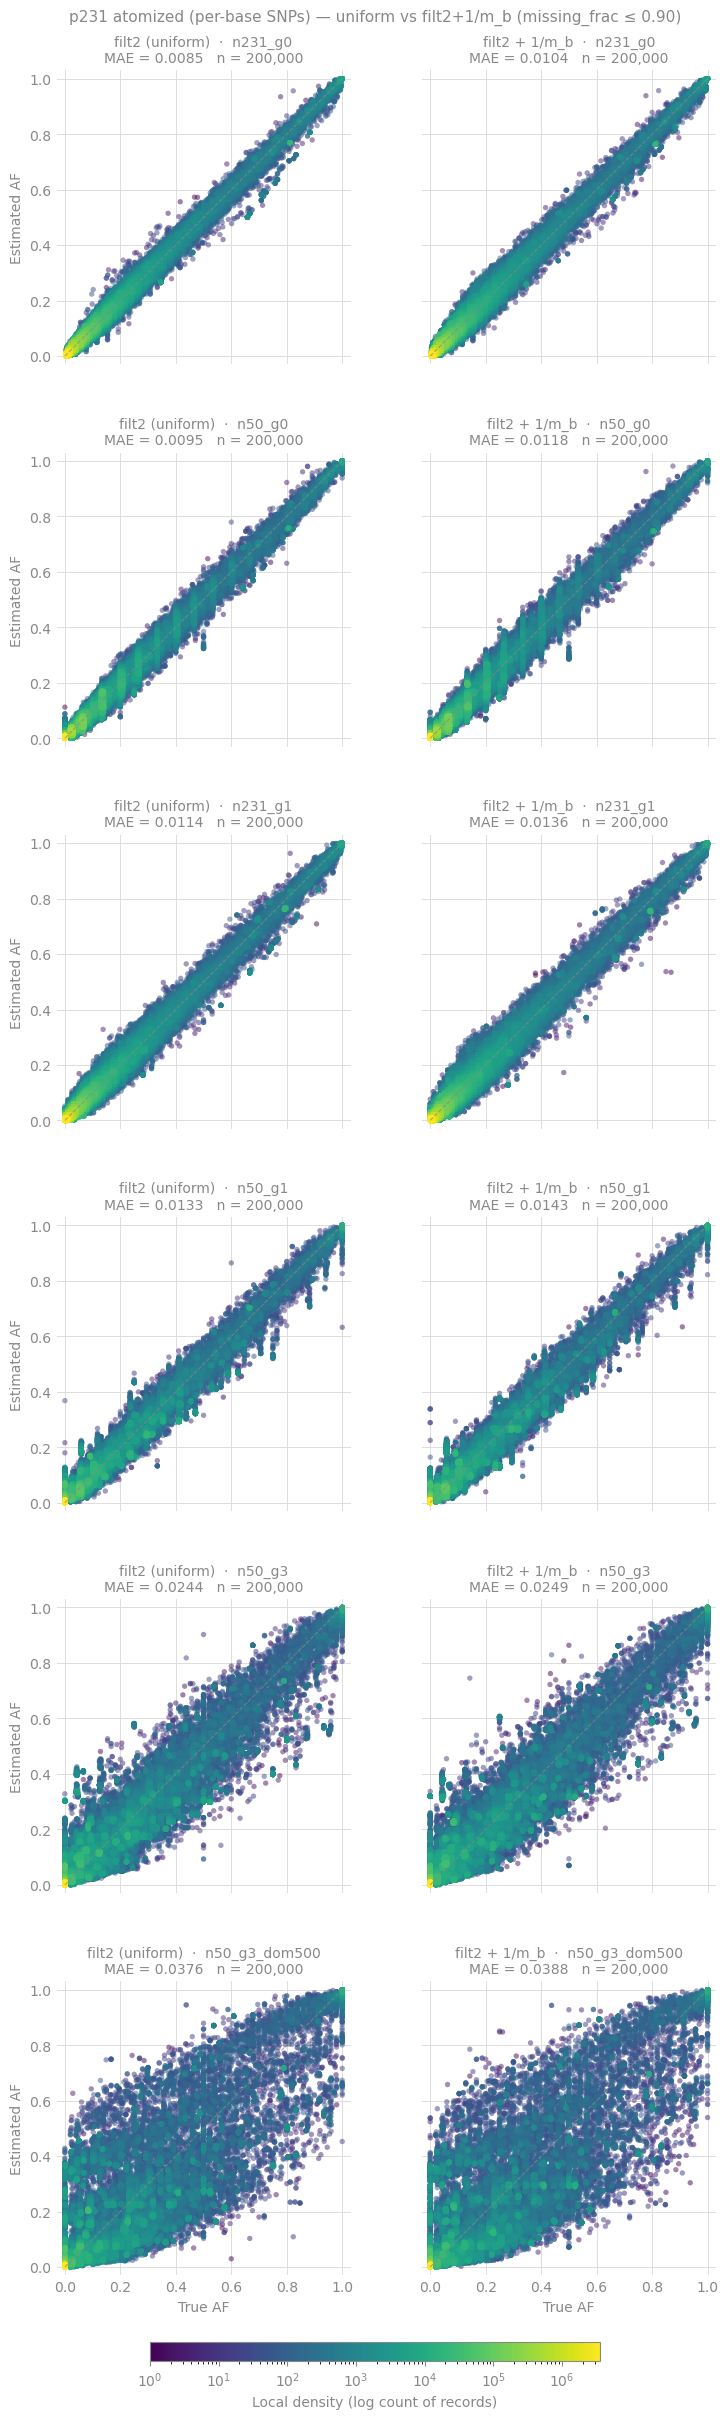

saved: plots/panel_p231_atom_uVm_miss90.png


In [5]:
panel(miss_thr=0.9, suptitle="p231 atomized (per-base SNPs) — uniform vs filt2+1/m_b (missing_frac ≤ 0.90)", filename="panel_p231_atom_uVm_miss90.png")

## Summary table — MAE / RMSE / outlier per regime × weight × missingness filter

In [6]:
out=[]
for reg in REGIMES:
    for w in WEIGHTS:
        truth,est,miss=load_cell(reg,w)
        for thr,lab in [(2.0,"no filter"),(0.90,"miss<=0.90"),(0.50,"miss<=0.50")]:
            sel=(miss<=thr)&np.isfinite(truth)&np.isfinite(est)
            t=truth[sel]; e=est[sel]; keep=(t>0)|(e>0); t=t[keep]; e=e[keep]
            if len(t)==0: continue
            d=e-t
            out.append(dict(regime=reg,weight=w,filter=lab,n=len(t),
                            MAE=float(np.abs(d).mean()),
                            RMSE=float(math.sqrt(np.mean(d**2))),
                            outlier=float(np.mean(np.abs(d)>0.10))))
        del truth,est,miss; gc.collect()
summ=pd.DataFrame(out)
pd.set_option("display.width",260,"display.max_columns",30,"display.max_rows",200)
summ.round(5)

,regime,weight,filter,n,MAE,RMSE,outlier
0,n231_g0,uniform,no filter,6356634,0.00878,0.01488,0.00330
1,n231_g0,uniform,miss<=0.90,6338115,0.00851,0.01364,0.00100
2,n231_g0,uniform,miss<=0.50,4419912,0.00763,0.01289,0.00135
3,n231_g0,inv_mb,no filter,6356634,0.01081,0.01845,0.00287
4,n231_g0,inv_mb,miss<=0.90,6338115,0.01043,0.01640,0.00056
5,n231_g0,inv_mb,miss<=0.50,4419912,0.00851,0.01377,0.00037
6,n50_g0,uniform,no filter,6278525,0.00958,0.01633,0.00072
7,n50_g0,uniform,miss<=0.90,6260010,0.00950,0.01620,0.00073
8,n50_g0,uniform,miss<=0.50,4341812,0.00816,0.01423,0.00067
9,n50_g0,inv_mb,no filter,6340645,0.01202,0.02066,0.00247
